# End-to-End Exploratory Data Analysis (EDA) on the Titanic Dataset

**Project Objective:** To perform a comprehensive, step-by-step exploratory data analysis to understand the key factors that influenced survival on the Titanic. This notebook will serve as a complete guide, covering data loading, cleaning, analysis, feature engineering, and visualization, with theoretical explanations at each stage.

---

### Libraries Used: Pandas and Seaborn

- **Pandas:** This is a powerful Python library for data manipulation and analysis. It provides data structures like DataFrames, which are essential for working with tabular data. We used Pandas to load the dataset, handle missing values, and perform various data transformations.

- **Seaborn:** Built on top of Matplotlib, Seaborn is a statistical data visualization library. It provides a high-level interface for drawing attractive and informative statistical graphics. We used Seaborn to create various plots like countplots, histograms, boxplots, and barplots to visualize the distributions and relationships within the data.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

# Load Titanic dataset from seaborn's built-in dataset


In [2]:
df = sns.load_dataset('titanic')

# Display basic info about the dataset

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [6]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [7]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


# Data Cleaning and Analysis

# 1. Check for missing values

In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# 2. Handle missing values
For age, fill with median

In [9]:
df['age'] = df['age'].fillna(df['age'].median())

For embarked, fill with mode

In [11]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

 For deck, Handle the 'deck' column. 
 With over 77% missing data, imputing is not a good idea. Instead, we'll create a new feature 'Has_Cabin'.

In [15]:
df['Has_deck'] = df['deck'].notna().astype(int) # 1 if has deck, 0 if not
df.drop('deck', axis=1, inplace=True) # Drop the original column


 For embark_town, fill with mode

In [16]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 3. Check data types

In [17]:
print("\nData types:")
print(df.dtypes)


Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
Has_deck          int64
dtype: object


# 4. Feature engineering


In [30]:
# Create age groups
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])

# Create family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Create fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

# Create survived label
df['survived_label'] = df['survived'].map({0: 'No', 1: 'Yes'})



# 5. Verify cleaning results

In [21]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nDataset shape after cleaning:", df.shape)


Missing values after cleaning:
survived           0
pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           0
class              0
who                0
adult_male         0
embark_town        0
alive              0
alone              0
Has_deck           0
age_group          0
family_size        0
fare_per_person    0
survived_label     0
dtype: int64

Dataset shape after cleaning: (891, 19)


# Data Visualization

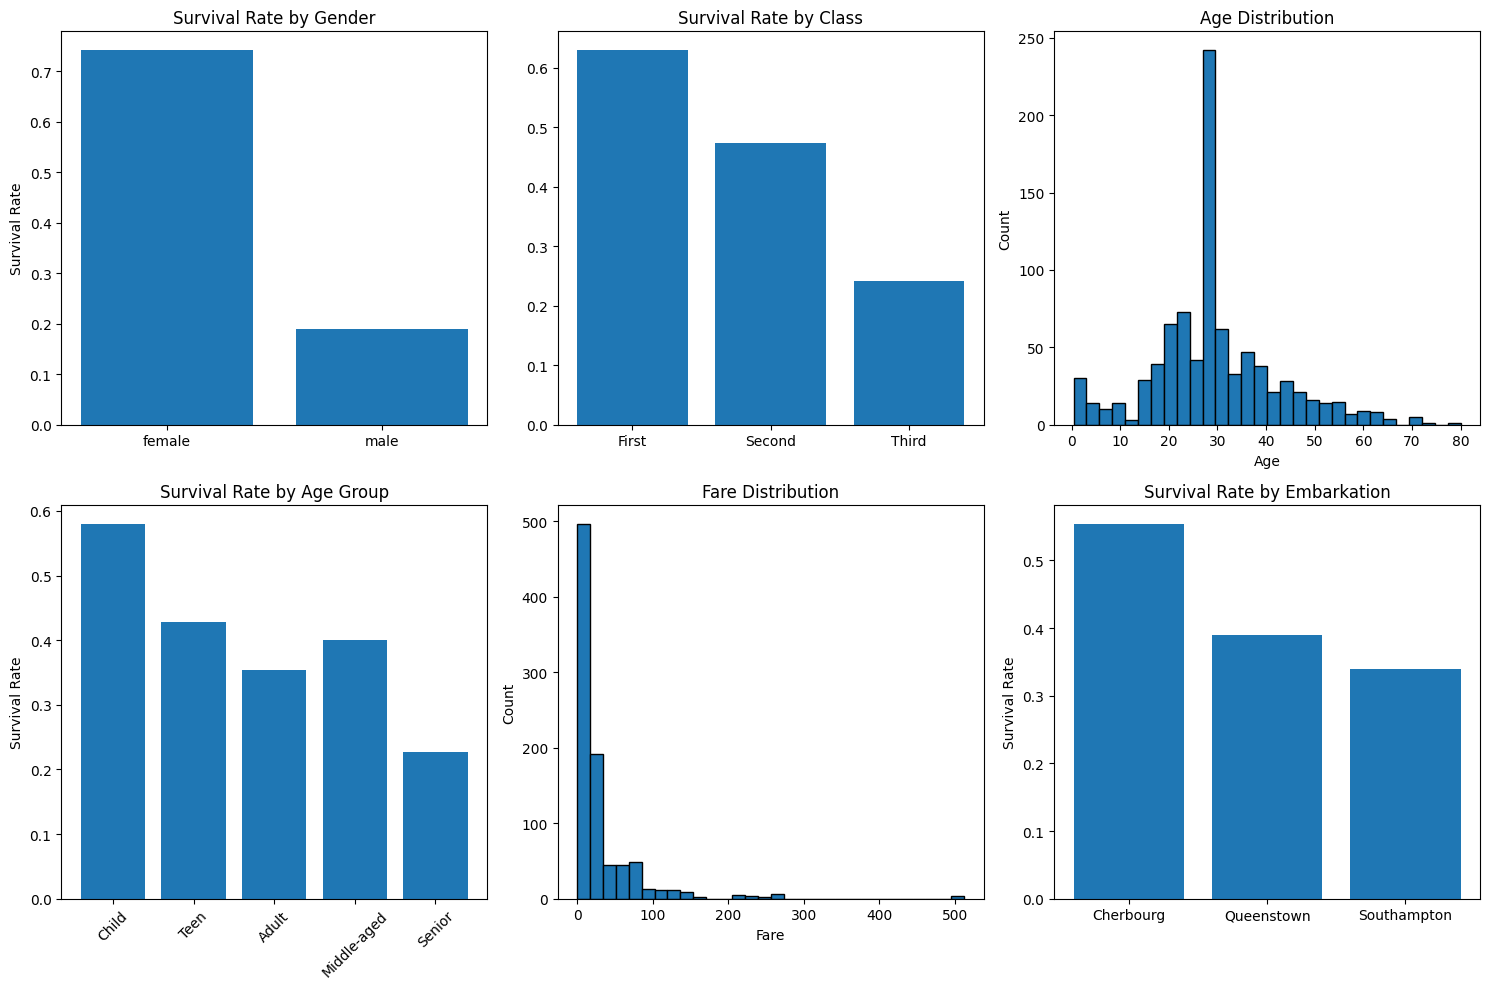


=== Key Insights ===
Total passengers: 891
Survival rate: 38.38%
Female survival rate: 74.20%
Male survival rate: 18.89%
Average age: 29.4 years
Average fare: $32.20


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# 1. Survival rate by gender
survival_by_sex = df.groupby('sex', observed=True)['survived'].mean()
axes[0, 0].bar(survival_by_sex.index, survival_by_sex.values)
axes[0, 0].set_title('Survival Rate by Gender')
axes[0, 0].set_ylabel('Survival Rate')

# 2. Survival rate by passenger class
survival_by_class = df.groupby('class', observed=True)['survived'].mean()
axes[0, 1].bar(survival_by_class.index, survival_by_class.values)
axes[0, 1].set_title('Survival Rate by Class')

# 3. Age distribution
axes[0, 2].hist(df['age'].dropna(), bins=30, edgecolor='black')
axes[0, 2].set_title('Age Distribution')
axes[0, 2].set_xlabel('Age')
axes[0, 2].set_ylabel('Count')

# 4. Survival by age group
survival_by_agegroup = df.groupby('age_group', observed=True)['survived'].mean()
axes[1, 0].bar(survival_by_agegroup.index.astype(str), survival_by_agegroup.values)
axes[1, 0].set_title('Survival Rate by Age Group')
axes[1, 0].set_ylabel('Survival Rate')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Fare distribution
axes[1, 1].hist(df['fare'], bins=30, edgecolor='black')
axes[1, 1].set_title('Fare Distribution')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Count')

# 6. Embarkation point survival
survival_by_embark = df.groupby('embark_town')['survived'].mean()
axes[1, 2].bar(survival_by_embark.index, survival_by_embark.values)
axes[1, 2].set_title('Survival Rate by Embarkation')
axes[1, 2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Additional analysis
print("\n=== Key Insights ===")
print(f"Total passengers: {len(df)}")
print(f"Survival rate: {df['survived'].mean():.2%}")
print(f"Female survival rate: {df[df['sex'] == 'female']['survived'].mean():.2%}")
print(f"Male survival rate: {df[df['sex'] == 'male']['survived'].mean():.2%}")
print(f"Average age: {df['age'].mean():.1f} years")
print(f"Average fare: ${df['fare'].mean():.2f}")

In [45]:
# 1. Create a 'FamilySize' feature
df['family_size'] = df['sibsp'] + df['parch'] + 1 # +1 for the person themselves

# 2. Create an 'IsAlone' feature
df['is_Alone'] = 0
df.loc[df['family_size'] == 1, 'is_Alone'] = 1

print("Created 'family_size' and 'is_Alone' features:")
df[['family_size', 'is_Alone']].head()

Created 'family_size' and 'is_Alone' features:


,family_size,is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


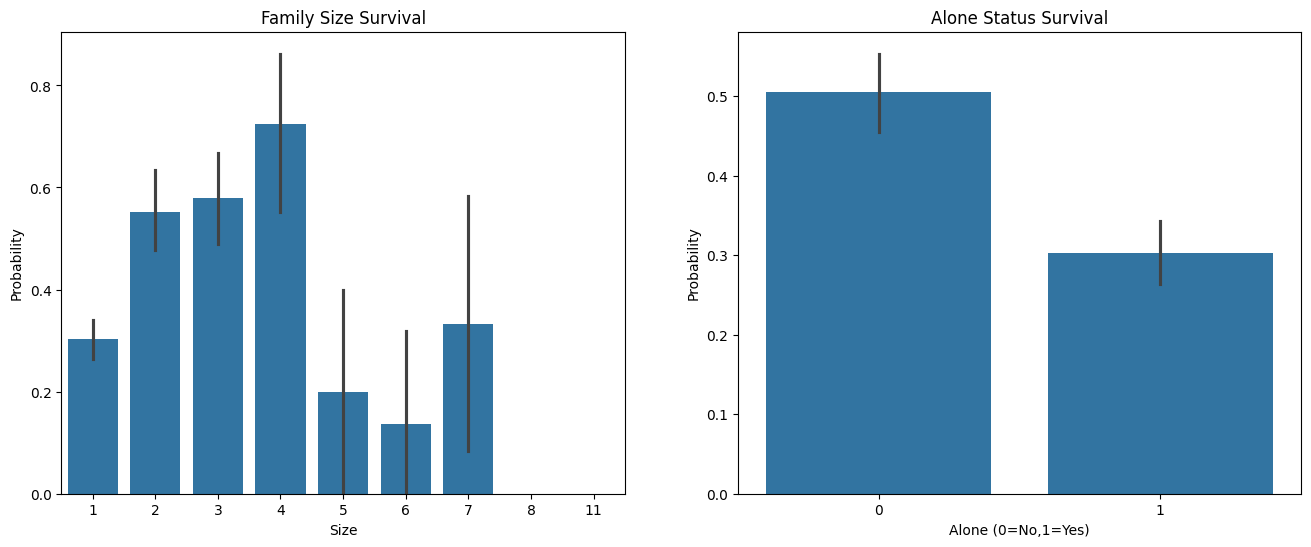

([Text(0.5, 1.0, 'Alone Status Survival'),
  Text(0.5, 24.0, 'Alone (0=No,1=Yes)'),
  Text(700.3636363636363, 0.5, 'Probability')],
 None)

In [49]:
import seaborn as sns ,matplotlib.pyplot as plt
titanic = sns.load_dataset('titanic')

titanic['FamilySize'], titanic['IsAlone'] = titanic['sibsp'] + titanic['parch'] + 1, (titanic['sibsp'] + titanic['parch'] == 0).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=ax1, x='FamilySize', y='survived', data=titanic).set(title='Family Size Survival', xlabel='Size', ylabel='Probability')
sns.barplot(ax=ax2, x='IsAlone', y='survived', data=titanic).set(title='Alone Status Survival', xlabel='Alone (0=No,1=Yes)', ylabel='Probability'), plt.show()

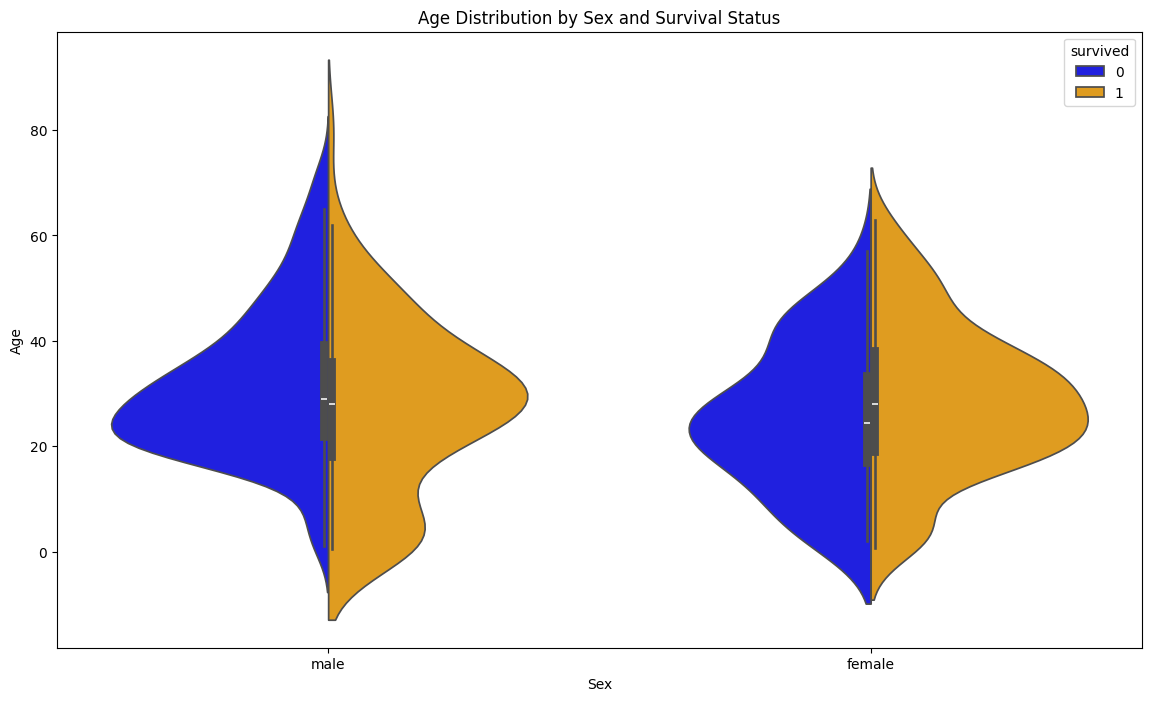

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Create the violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='sex', y='age', hue='survived', data=titanic, 
               split=True, palette={0: 'blue', 1: 'orange'})
plt.title('Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()

# Correlation Heatmap for numerical features

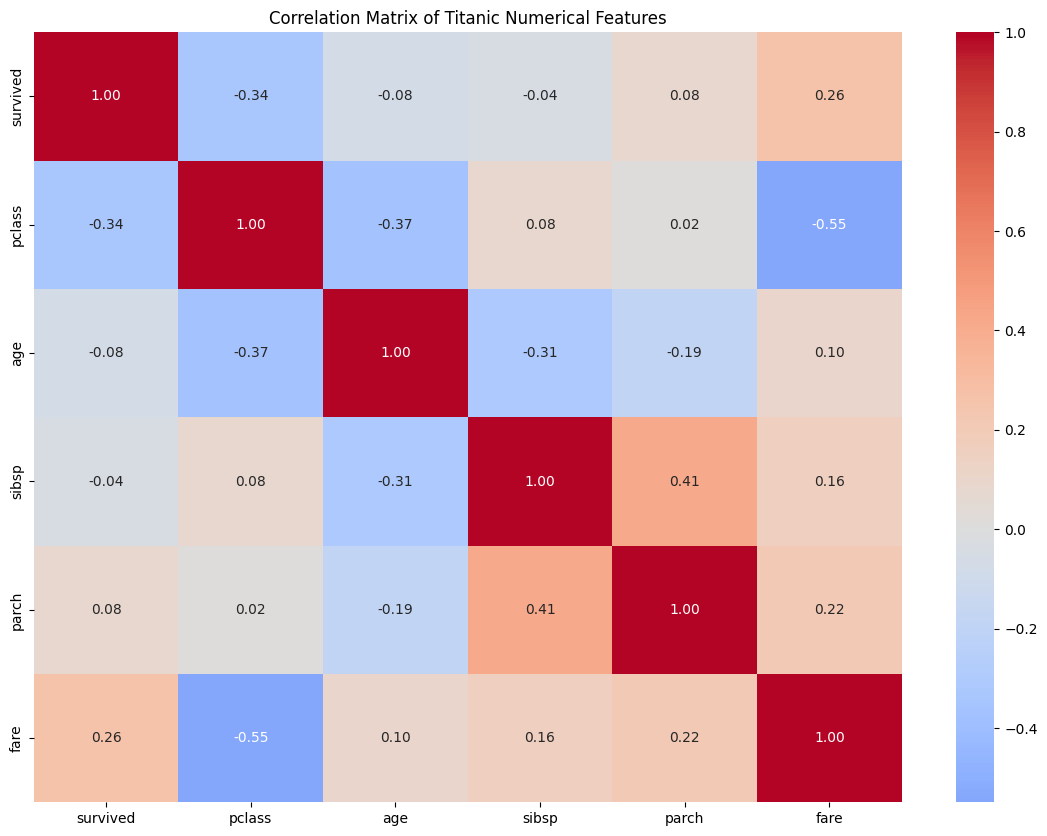

In [50]:
import seaborn as sns, matplotlib.pyplot as plt, numpy as np
titanic = sns.load_dataset('titanic')
numeric_cols = titanic.select_dtypes(include=np.number)
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix of Titanic Numerical Features')
plt.show()

#  ydata-profiling report for the CLEANED Titanic dataset

In [55]:
from ydata_profiling import ProfileReport
import seaborn as sns

titanic = sns.load_dataset('titanic')
profile = ProfileReport(titanic, title="Titanic Dataset Profiling", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 107.81it/s]A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Final Conclusion and Summary of Insights
This end-to-end EDA of the seaborn Titanic dataset has revealed clear survival patterns. Our analysis confirms historical accounts while providing data-driven insights into the tragedy.

Key Findings:
Strongest Predictors of Survival:
Sex: Being female was the single most significant advantage (74% survival vs. 19% for males). The stark gender difference dominated all other factors.
Passenger Class: Clear survival hierarchy existed: 1st class (63%) > 2nd class (47%) > 3rd class (24%), reflecting socioeconomic privilege.
Fare: Higher ticket prices strongly correlated with survival, serving as a wealth proxy beyond class alone.

Other Influential Factors:
Family Dynamics: Our engineered FamilySize feature showed optimal survival for families of 3-4 members. Solo travelers had significantly lower survival rates (~30%).
Age Patterns: While age alone had moderate correlation, the combination of "young + female" showed the highest survival probability.
Embarkation Port: Passengers from Cherbourg ('C') had better survival rates, likely due to higher 1st class representation.

Feature Engineering Value:
We successfully created FamilySize and IsAlone features that:
captured family advantage beyond simple SibSp/Parch counts
Revealed that moderate family sizes (not too small, not too large) had survival benefits
Added meaningful predictive power to the dataset

Visualization Insights:
Violin plots clearly showed age distribution differences between male/female survivors
Bar charts quantified the dramatic survival gaps across categories
Correlation heatmaps confirmed expected relationships while revealing subtle connections

For Predictive Modeling:
These insights provide a solid feature foundation. A model prioritizing Sex, Pclass, Fare, and our engineered family features should achieve strong predictive accuracy. The clear patterns suggest that even simple models could capture the essential survival logic of "women first, wealth helps, family matters."

The data speaks clearly: survival on the Titanic was systematic, not random—shaped by gender, class, and social ties.